In [ ]:
# Import required libraries for data processing, modelling, evaluation, visualisation, and file handling.
import os
import zipfile
import time
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
# Use GPU for PyTorch model training.
# Ensure you have enabled GPU in Runtime -> Change runtime type
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
"Runtime → Change runtime type → GPU" + ("This is because for better solutions than CPU")

'Runtime → Change runtime type → GPUThis is because for better solutions than CPU'

In [ ]:
# Extracting the locally provided MovieLens 1M dataset.
import os
import zipfile
import shutil

local_zip = "/content/archive (1).zip"
print(f"Extracting local dataset from {local_zip}...")

# Extract everything to a temporary folder
with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall("tmp_extract")

# Create the expected directory for downstream cells
os.makedirs("ml-1m", exist_ok=True)

# Find ratings.dat and move it to the expected path
data_path = "ml-1m/ratings.dat"
for root, dirs, files in os.walk("tmp_extract"):
    if "ratings.dat" in files:
        source_path = os.path.join(root, "ratings.dat")
        shutil.move(source_path, data_path)
        break

if os.path.exists(data_path):
    print("Dataset path:", data_path)
else:
    print("Failed to find ratings.dat in the provided archive.")


Extracting local dataset from /content/archive (1).zip...
Dataset path: ml-1m/ratings.dat


In [ ]:
# Defining experiment settings for reproducibility, sparsity control, model training, and evaluation.
@dataclass
class Config:
    data_path: str = "ml-1m/ratings.dat"
    seed: int = 42

    # Dataset filtering
    min_user_interactions: int = 5
    min_item_interactions: int = 5
    implicit_threshold: float = 4.0

    # Sparsity settings
    sparsity_keep_rates: Tuple[float, ...] = (1.0, 0.7, 0.5, 0.3, 0.1)

    # Evaluation
    top_k: int = 10

    # MF settings
    mf_factors: int = 32
    mf_learning_rate: float = 0.01
    mf_reg: float = 0.01
    mf_epochs: int = 10

    # NCF settings
    ncf_embedding_dim: int = 32
    ncf_hidden_layers: Tuple[int, ...] = (64, 32, 16)
    ncf_dropout: float = 0.2
    ncf_learning_rate: float = 0.001
    ncf_batch_size: int = 1024
    ncf_epochs: int = 5

    # Negative sampling
    negative_ratio: int = 4


CFG = Config()
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)

print(CFG)

Config(data_path='ml-1m/ratings.dat', seed=42, min_user_interactions=5, min_item_interactions=5, implicit_threshold=4.0, sparsity_keep_rates=(1.0, 0.7, 0.5, 0.3, 0.1), top_k=10, mf_factors=32, mf_learning_rate=0.01, mf_reg=0.01, mf_epochs=10, ncf_embedding_dim=32, ncf_hidden_layers=(64, 32, 16), ncf_dropout=0.2, ncf_learning_rate=0.001, ncf_batch_size=1024, ncf_epochs=5, negative_ratio=4)


In [ ]:
# Loading the MovieLens 1M ratings file into a structured pandas DataFrame.
def load_movielens_1m(path: str) -> pd.DataFrame:
    """
    MovieLens 1M ratings.dat format:
    UserID::MovieID::Rating::Timestamp
    """
    df = pd.read_csv(
        path,
        sep="::",
        engine="python",
        header=None,
        names=["user_id", "item_id", "rating", "timestamp"],
        encoding="latin-1"
    )
    return df


ratings = load_movielens_1m(CFG.data_path)
ratings.head()

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [ ]:

def preprocess_interactions(df: pd.DataFrame, implicit_threshold: float = 4.0) -> pd.DataFrame:
    df = df.copy()
    df = df[df["rating"] >= implicit_threshold].copy()
    df["interaction"] = 1
    return df[["user_id", "item_id", "interaction", "timestamp"]]


interactions = preprocess_interactions(ratings, CFG.implicit_threshold)

print("Original ratings:", len(ratings))
print("Positive implicit interactions:", len(interactions))
interactions.head()

Original ratings: 1000209
Positive implicit interactions: 575281


,user_id,item_id,interaction,timestamp
0,1,1193,1,978300760
3,1,3408,1,978300275
4,1,2355,1,978824291
6,1,1287,1,978302039
7,1,2804,1,978300719


In [ ]:
def filter_min_interactions(
    df: pd.DataFrame,
    min_user_interactions: int = 5,
    min_item_interactions: int = 5
) -> pd.DataFrame:
    filtered = df.copy()

    while True:
        before_len = len(filtered)

        user_counts = filtered.groupby("user_id")["item_id"].count()
        valid_users = user_counts[user_counts >= min_user_interactions].index
        filtered = filtered[filtered["user_id"].isin(valid_users)]

        item_counts = filtered.groupby("item_id")["user_id"].count()
        valid_items = item_counts[item_counts >= min_item_interactions].index
        filtered = filtered[filtered["item_id"].isin(valid_items)]

        if len(filtered) == before_len:
            break

    return filtered.reset_index(drop=True)


interactions = filter_min_interactions(
    interactions,
    CFG.min_user_interactions,
    CFG.min_item_interactions
)

print("Filtered interactions:", len(interactions))
print("Users:", interactions["user_id"].nunique())
print("Items:", interactions["item_id"].nunique())

Filtered interactions: 574376
Users: 6034
Items: 3125


In [ ]:
def encode_ids(df: pd.DataFrame):
    df = df.copy()

    user_map = {u: i for i, u in enumerate(sorted(df["user_id"].unique()))}
    item_map = {m: i for i, m in enumerate(sorted(df["item_id"].unique()))}

    df["user_idx"] = df["user_id"].map(user_map)
    df["item_idx"] = df["item_id"].map(item_map)

    return df, user_map, item_map


interactions, user_map, item_map = encode_ids(interactions)

n_users = interactions["user_idx"].nunique()
n_items = interactions["item_idx"].nunique()

print("Encoded users:", n_users)
print("Encoded items:", n_items)
interactions.head()

Encoded users: 6034
Encoded items: 3125


,user_id,item_id,interaction,timestamp,user_idx,item_idx
0,1,1193,1,978300760,0,924
1,1,3408,1,978300275,0,2685
2,1,2355,1,978824291,0,1835
3,1,1287,1,978302039,0,1015
4,1,2804,1,978300719,0,2218


In [ ]:
"last interaction per user = test"


'last interaction per user = test'

In [ ]:
"second-last interaction per user = validation"


'second-last interaction per user = validation'

In [ ]:
"remaining interactions = train"

'remaining interactions = train'

In [ ]:
def userwise_leave_one_out_split(df: pd.DataFrame):
    df = df.sort_values(["user_idx", "timestamp"]).copy()

    train_parts = []
    val_parts = []
    test_parts = []

    for _, group in df.groupby("user_idx"):
        if len(group) < 3:
            continue

        train_parts.append(group.iloc[:-2])
        val_parts.append(group.iloc[-2:-1])
        test_parts.append(group.iloc[-1:])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = userwise_leave_one_out_split(interactions)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 562308
Validation: 6034
Test: 6034


In [ ]:
# **Dataset statistics**

In [ ]:
def dataset_stats(df: pd.DataFrame, label: str):
    users = df["user_idx"].nunique()
    items = df["item_idx"].nunique()
    interactions_count = len(df)
    density = interactions_count / (users * items) if users > 0 and items > 0 else 0

    return {
        "label": label,
        "users": users,
        "items": items,
        "interactions": interactions_count,
        "density": density,
        "sparsity": 1 - density
    }


stats_df = pd.DataFrame([
    dataset_stats(train_df, "train"),
    dataset_stats(val_df, "validation"),
    dataset_stats(test_df, "test")
])

stats_df

,label,users,items,interactions,density,sparsity
0,train,6034,3125,562308,0.029821,0.970179
1,validation,6034,1768,6034,0.000566,0.999434
2,test,6034,1798,6034,0.000556,0.999444


In [ ]:
print("Controlled sparsity function")

Controlled sparsity function


In [ ]:
def apply_controlled_sparsity(
    train_df: pd.DataFrame,
    keep_rate: float,
    seed: int = 42
) -> pd.DataFrame:
    """
    Reduces training interactions while preserving at least one interaction per user.
    keep_rate = 1.0 means full training data.
    keep_rate = 0.1 means only 10% of each user's training interactions.
    """
    if keep_rate >= 1.0:
        return train_df.copy().reset_index(drop=True)

    rng = np.random.default_rng(seed)
    sampled_parts = []

    for _, group in train_df.groupby("user_idx"):
        n = len(group)
        keep_n = max(1, int(np.ceil(n * keep_rate)))
        chosen_idx = rng.choice(group.index.to_numpy(), size=keep_n, replace=False)
        sampled_parts.append(train_df.loc[chosen_idx])

    sparse_df = pd.concat(sampled_parts).sort_values(["user_idx", "timestamp"])
    return sparse_df.reset_index(drop=True)


for keep_rate in CFG.sparsity_keep_rates:
    sparse_train = apply_controlled_sparsity(train_df, keep_rate, CFG.seed)
    print(keep_rate, len(sparse_train))

1.0 562308
0.7 396290
0.5 282674
0.3 171440
0.1 58922


In [ ]:
print("Helper functions for seen items and negative sampling")

Helper functions for seen items and negative sampling


In [ ]:
def build_seen_items(df: pd.DataFrame) -> Dict[int, set]:
    seen = {}

    for user_idx, group in df.groupby("user_idx"):
        seen[int(user_idx)] = set(group["item_idx"].tolist())

    return seen


def generate_binary_training_data(
    train_df: pd.DataFrame,
    n_items: int,
    negative_ratio: int = 4,
    seed: int = 42
) -> pd.DataFrame:
    """
    Creates positive and negative examples.
    Positive = observed interaction
    Negative = sampled unobserved item for the same user
    """
    rng = np.random.default_rng(seed)

    positive = train_df[["user_idx", "item_idx"]].copy()
    positive["label"] = 1.0

    seen_items = build_seen_items(train_df)
    negative_rows = []

    for user_idx, group in train_df.groupby("user_idx"):
        user_idx = int(user_idx)
        user_seen = seen_items[user_idx]

        n_negatives = len(group) * negative_ratio
        sampled = 0
        attempts = 0
        max_attempts = max(n_negatives * 20, 100)

        while sampled < n_negatives and attempts < max_attempts:
            item_idx = int(rng.integers(0, n_items))
            attempts += 1

            if item_idx in user_seen:
                continue

            negative_rows.append({
                "user_idx": user_idx,
                "item_idx": item_idx,
                "label": 0.0
            })
            sampled += 1

    negative = pd.DataFrame(negative_rows)

    binary_data = pd.concat([positive, negative], ignore_index=True)
    binary_data = binary_data.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return binary_data

In [ ]:
print("MFModel")

MFModel


In [ ]:
class MatrixFactorization:
    """
    Simple Matrix Factorization baseline for implicit feedback.
    Trained with binary positive/negative samples.
    """

    def __init__(
        self,
        n_users: int,
        n_items: int,
        n_factors: int = 32,
        learning_rate: float = 0.01,
        reg: float = 0.01,
        n_epochs: int = 10,
        seed: int = 42
    ):
        self.n_users = n_users
        self.n_items = n_items
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.reg = reg
        self.n_epochs = n_epochs

        self.rng = np.random.default_rng(seed)

        self.user_factors = self.rng.normal(0, 0.1, size=(n_users, n_factors))
        self.item_factors = self.rng.normal(0, 0.1, size=(n_items, n_factors))
        self.user_bias = np.zeros(n_users)
        self.item_bias = np.zeros(n_items)
        self.global_bias = 0.0

    def predict_single(self, user_idx: int, item_idx: int) -> float:
        score = (
            self.global_bias
            + self.user_bias[user_idx]
            + self.item_bias[item_idx]
            + np.dot(self.user_factors[user_idx], self.item_factors[item_idx])
        )
        return float(score)

    def fit(self, train_binary: pd.DataFrame) -> List[float]:
        rows = train_binary[["user_idx", "item_idx", "label"]].to_numpy()
        self.global_bias = float(train_binary["label"].mean())

        losses = []

        for epoch in range(self.n_epochs):
            self.rng.shuffle(rows)
            epoch_loss = 0.0

            for user_idx, item_idx, label in rows:
                user_idx = int(user_idx)
                item_idx = int(item_idx)
                label = float(label)

                pred = self.predict_single(user_idx, item_idx)
                err = label - pred
                epoch_loss += err ** 2

                user_vec = self.user_factors[user_idx].copy()
                item_vec = self.item_factors[item_idx].copy()

                self.user_bias[user_idx] += self.learning_rate * (
                    err - self.reg * self.user_bias[user_idx]
                )
                self.item_bias[item_idx] += self.learning_rate * (
                    err - self.reg * self.item_bias[item_idx]
                )

                self.user_factors[user_idx] += self.learning_rate * (
                    err * item_vec - self.reg * user_vec
                )
                self.item_factors[item_idx] += self.learning_rate * (
                    err * user_vec - self.reg * item_vec
                )

            mean_loss = epoch_loss / len(rows)
            losses.append(mean_loss)

            print(f"MF Epoch {epoch + 1}/{self.n_epochs} - loss: {mean_loss:.6f}")

        return losses

    def recommend_top_k(self, user_idx: int, seen_items: set, k: int = 10) -> List[int]:
        scores = []

        for item_idx in range(self.n_items):
            if item_idx in seen_items:
                continue

            score = self.predict_single(user_idx, item_idx)
            scores.append((item_idx, score))

        scores.sort(key=lambda x: x[1], reverse=True)

        return [item for item, _ in scores[:k]]

In [ ]:
print("PyTorch NCF dataset and model")

PyTorch NCF dataset and model


In [ ]:
class InteractionDataset(Dataset):
    def __init__(self, interactions: pd.DataFrame):
        self.users = torch.tensor(interactions["user_idx"].values, dtype=torch.long)
        self.items = torch.tensor(interactions["item_idx"].values, dtype=torch.long)
        self.labels = torch.tensor(interactions["label"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]


class NeuralCollaborativeFiltering(nn.Module):
    def __init__(
        self,
        n_users: int,
        n_items: int,
        embedding_dim: int = 32,
        hidden_layers: Tuple[int, ...] = (64, 32, 16),
        dropout: float = 0.2
    ):
        super().__init__()

        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        layers = []
        input_dim = embedding_dim * 2

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, 1))

        self.mlp = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)

        for layer in self.mlp:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, users, items):
        user_vec = self.user_embedding(users)
        item_vec = self.item_embedding(items)

        x = torch.cat([user_vec, item_vec], dim=-1)

        logits = self.mlp(x).squeeze(-1)

        return logits

In [ ]:
print("NCF recommender wrapper")

NCF recommender wrapper


In [ ]:
class NCFRecommender:
    def __init__(
        self,
        n_users: int,
        n_items: int,
        embedding_dim: int = 32,
        hidden_layers: Tuple[int, ...] = (64, 32, 16),
        dropout: float = 0.2,
        learning_rate: float = 0.001,
        batch_size: int = 1024,
        n_epochs: int = 5,
        seed: int = 42,
        device: str = "cpu"
    ):
        self.n_users = n_users
        self.n_items = n_items
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.seed = seed
        self.device = torch.device(device)

        torch.manual_seed(seed)

        self.model = NeuralCollaborativeFiltering(
            n_users=n_users,
            n_items=n_items,
            embedding_dim=embedding_dim,
            hidden_layers=hidden_layers,
            dropout=dropout
        ).to(self.device)

    def fit(self, train_binary: pd.DataFrame) -> List[float]:
        dataset = InteractionDataset(train_binary)
        dataloader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=True
        )

        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.learning_rate
        )

        criterion = nn.BCEWithLogitsLoss()

        losses = []

        self.model.train()

        for epoch in range(self.n_epochs):
            epoch_loss = 0.0
            n_batches = 0

            for users, items, labels in dataloader:
                users = users.to(self.device)
                items = items.to(self.device)
                labels = labels.to(self.device)

                optimizer.zero_grad()

                logits = self.model(users, items)
                loss = criterion(logits, labels)

                loss.backward()
                optimizer.step()

                epoch_loss += float(loss.item())
                n_batches += 1

            mean_loss = epoch_loss / n_batches
            losses.append(mean_loss)

            print(f"NCF Epoch {epoch + 1}/{self.n_epochs} - loss: {mean_loss:.6f}")

        return losses

    def predict_single(self, user_idx: int, item_idx: int) -> float:
        self.model.eval()

        with torch.no_grad():
            user_tensor = torch.tensor([user_idx], dtype=torch.long).to(self.device)
            item_tensor = torch.tensor([item_idx], dtype=torch.long).to(self.device)

            logit = self.model(user_tensor, item_tensor)
            score = torch.sigmoid(logit).item()

        return float(score)

    def recommend_top_k(self, user_idx: int, seen_items: set, k: int = 10) -> List[int]:
        self.model.eval()

        candidate_items = [
            item_idx for item_idx in range(self.n_items)
            if item_idx not in seen_items
        ]

        if len(candidate_items) == 0:
            return []

        users = torch.full(
            (len(candidate_items),),
            user_idx,
            dtype=torch.long
        ).to(self.device)

        items = torch.tensor(
            candidate_items,
            dtype=torch.long
        ).to(self.device)

        with torch.no_grad():
            logits = self.model(users, items)
            scores = torch.sigmoid(logits).detach().cpu().numpy()

        ranked_indices = np.argsort(scores)[::-1][:k]

        return [candidate_items[i] for i in ranked_indices]

In [ ]:
print("Evaluation metrics")

Evaluation metrics


In [ ]:
def hit_rate_at_k(recommended_items: List[int], true_item: int, k: int = 10) -> float:
    return float(true_item in recommended_items[:k])


def ndcg_at_k(recommended_items: List[int], true_item: int, k: int = 10) -> float:
    top_k_items = recommended_items[:k]

    if true_item in top_k_items:
        rank = top_k_items.index(true_item) + 1
        return 1.0 / np.log2(rank + 1)

    return 0.0


def recall_at_k(recommended_items: List[int], true_items: set, k: int = 10) -> float:
    if not true_items:
        return 0.0

    hits = len(set(recommended_items[:k]).intersection(true_items))

    return hits / len(true_items)


def evaluate_model_ranking(
    model,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    k: int = 10
) -> Dict[str, float]:
    seen_items_by_user = build_seen_items(train_df)

    hr_scores = []
    ndcg_scores = []
    recall_scores = []

    evaluated_users = 0

    for user_idx, group in test_df.groupby("user_idx"):
        user_idx = int(user_idx)
        true_items = set(group["item_idx"].tolist())

        if not true_items:
            continue

        seen_items = seen_items_by_user.get(user_idx, set())

        recommended_items = model.recommend_top_k(
            user_idx=user_idx,
            seen_items=seen_items,
            k=k
        )

        true_item = next(iter(true_items))

        hr_scores.append(hit_rate_at_k(recommended_items, true_item, k))
        ndcg_scores.append(ndcg_at_k(recommended_items, true_item, k))
        recall_scores.append(recall_at_k(recommended_items, true_items, k))

        evaluated_users += 1

    return {
        "HR@K": float(np.mean(hr_scores)),
        "NDCG@K": float(np.mean(ndcg_scores)),
        "Recall@K": float(np.mean(recall_scores)),
        "evaluated_users": evaluated_users
    }

In [ ]:
print("Taking a test for MF and NCF across sparsity levels")

Taking a test for MF and NCF across sparsity levels


In [ ]:
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

comparison_results = []
training_loss_rows = []

start_time = time.time()

for keep_rate in CFG.sparsity_keep_rates:
    print("\n" + "=" * 70)
    print(f"Sparsity experiment | keep_rate = {keep_rate}")
    print("=" * 70)

    sparse_train = apply_controlled_sparsity(
        train_df,
        keep_rate,
        seed=CFG.seed
    )

    train_density = dataset_stats(sparse_train, "sparse_train")["density"]

    train_binary = generate_binary_training_data(
        train_df=sparse_train,
        n_items=n_items,
        negative_ratio=CFG.negative_ratio,
        seed=CFG.seed
    )

    print("Sparse train interactions:", len(sparse_train))
    print("Binary training rows:", len(train_binary))

    # ------------------------------------------------------------
    # Matrix Factorization
    # ------------------------------------------------------------
    print("\nTraining Matrix Factorization...")

    mf = MatrixFactorization(
        n_users=n_users,
        n_items=n_items,
        n_factors=CFG.mf_factors,
        learning_rate=CFG.mf_learning_rate,
        reg=CFG.mf_reg,
        n_epochs=CFG.mf_epochs,
        seed=CFG.seed
    )

    mf_start = time.time()
    mf_losses = mf.fit(train_binary)
    mf_training_time = time.time() - mf_start

    for epoch, loss in enumerate(mf_losses, start=1):
        training_loss_rows.append({
            "model": "MF",
            "keep_rate": keep_rate,
            "sparsity_level": 1.0 - keep_rate,
            "epoch": epoch,
            "loss": loss
        })

    mf_metrics = evaluate_model_ranking(
        model=mf,
        train_df=sparse_train,
        test_df=test_df,
        k=CFG.top_k
    )

    comparison_results.append({
        "model": "MF",
        "keep_rate": keep_rate,
        "sparsity_level": 1.0 - keep_rate,
        "k": CFG.top_k,
        "hr": mf_metrics["HR@K"],
        "ndcg": mf_metrics["NDCG@K"],
        "recall": mf_metrics["Recall@K"],
        "evaluated_users": mf_metrics["evaluated_users"],
        "train_interactions": len(sparse_train),
        "train_density": train_density,
        "training_time_seconds": mf_training_time
    })

    print(f"MF HR@{CFG.top_k}: {mf_metrics['HR@K']:.4f}")
    print(f"MF NDCG@{CFG.top_k}: {mf_metrics['NDCG@K']:.4f}")
    print(f"MF Recall@{CFG.top_k}: {mf_metrics['Recall@K']:.4f}")
    print(f"MF training time: {mf_training_time:.2f} seconds")

    # ------------------------------------------------------------
    # Neural Collaborative Filtering
    # ------------------------------------------------------------
    print("\nTraining Neural Collaborative Filtering...")

    ncf = NCFRecommender(
        n_users=n_users,
        n_items=n_items,
        embedding_dim=CFG.ncf_embedding_dim,
        hidden_layers=CFG.ncf_hidden_layers,
        dropout=CFG.ncf_dropout,
        learning_rate=CFG.ncf_learning_rate,
        batch_size=CFG.ncf_batch_size,
        n_epochs=CFG.ncf_epochs,
        seed=CFG.seed,
        device=device
    )

    ncf_start = time.time()
    ncf_losses = ncf.fit(train_binary)
    ncf_training_time = time.time() - ncf_start

    for epoch, loss in enumerate(ncf_losses, start=1):
        training_loss_rows.append({
            "model": "NCF",
            "keep_rate": keep_rate,
            "sparsity_level": 1.0 - keep_rate,
            "epoch": epoch,
            "loss": loss
        })

    ncf_metrics = evaluate_model_ranking(
        model=ncf,
        train_df=sparse_train,
        test_df=test_df,
        k=CFG.top_k
    )

    comparison_results.append({
        "model": "NCF",
        "keep_rate": keep_rate,
        "sparsity_level": 1.0 - keep_rate,
        "k": CFG.top_k,
        "hr": ncf_metrics["HR@K"],
        "ndcg": ncf_metrics["NDCG@K"],
        "recall": ncf_metrics["Recall@K"],
        "evaluated_users": ncf_metrics["evaluated_users"],
        "train_interactions": len(sparse_train),
        "train_density": train_density,
        "training_time_seconds": ncf_training_time
    })

    print(f"NCF HR@{CFG.top_k}: {ncf_metrics['HR@K']:.4f}")
    print(f"NCF NDCG@{CFG.top_k}: {ncf_metrics['NDCG@K']:.4f}")
    print(f"NCF Recall@{CFG.top_k}: {ncf_metrics['Recall@K']:.4f}")
    print(f"NCF training time: {ncf_training_time:.2f} seconds")


total_time = time.time() - start_time
print("\nTotal experiment time:", round(total_time, 2), "seconds")


Sparsity experiment | keep_rate = 1.0
Sparse train interactions: 562308
Binary training rows: 2811540

Training Matrix Factorization...
MF Epoch 1/10 - loss: 0.117616
MF Epoch 2/10 - loss: 0.113592
MF Epoch 3/10 - loss: 0.112294
MF Epoch 4/10 - loss: 0.110578
MF Epoch 5/10 - loss: 0.107490
MF Epoch 6/10 - loss: 0.103403
MF Epoch 7/10 - loss: 0.099483
MF Epoch 8/10 - loss: 0.096039
MF Epoch 9/10 - loss: 0.093201
MF Epoch 10/10 - loss: 0.090875
MF HR@10: 0.0457
MF NDCG@10: 0.0218
MF Recall@10: 0.0457
MF training time: 575.50 seconds

Training Neural Collaborative Filtering...
NCF Epoch 1/5 - loss: 0.368247
NCF Epoch 2/5 - loss: 0.342051
NCF Epoch 3/5 - loss: 0.318761
NCF Epoch 4/5 - loss: 0.304912
NCF Epoch 5/5 - loss: 0.292568
NCF HR@10: 0.0572
NCF NDCG@10: 0.0279
NCF Recall@10: 0.0572
NCF training time: 179.17 seconds

Sparsity experiment | keep_rate = 0.7
Sparse train interactions: 396290
Binary training rows: 1981450

Training Matrix Factorization...
MF Epoch 1/10 - loss: 0.121526
M

In [ ]:
# This cell saves the experimental results as CSV files.
# The first file contains the model comparison metrics.
# The second file contains the training loss values for each model and sparsity level.

comparison_results_df = pd.DataFrame(comparison_results)
training_loss_df = pd.DataFrame(training_loss_rows)

comparison_results_df.to_csv(
    out_dir / "model_comparison_sparsity_results.csv",
    index=False
)

training_loss_df.to_csv(
    out_dir / "model_comparison_training_losses.csv",
    index=False
)

comparison_results_df

,model,keep_rate,sparsity_level,k,hr,ndcg,recall,evaluated_users,train_interactions,train_density,training_time_seconds
0,MF,1.0,0.0,10,0.045741,0.021815,0.045741,6034,562308,0.029821,575.500384
1,NCF,1.0,0.0,10,0.057176,0.027919,0.057176,6034,562308,0.029821,179.165781
2,MF,0.7,0.3,10,0.031820,0.014464,0.031820,6034,396290,0.021016,397.332693
3,NCF,0.7,0.3,10,0.038117,0.017611,0.038117,6034,396290,0.021016,122.981029
4,MF,0.5,0.5,10,0.028174,0.012691,0.028174,6034,282674,0.015020,291.738901
5,NCF,0.5,0.5,10,0.027842,0.012935,0.027842,6034,282674,0.015020,88.412569
6,MF,0.3,0.7,10,0.024693,0.011913,0.024693,6034,171440,0.009189,179.863916
7,NCF,0.3,0.7,10,0.028505,0.013458,0.028505,6034,171440,0.009189,53.066469
8,MF,0.1,0.9,10,0.026848,0.012604,0.026848,6034,58922,0.003457,60.292444
9,NCF,0.1,0.9,10,0.027179,0.014707,0.027179,6034,58922,0.003457,18.423622


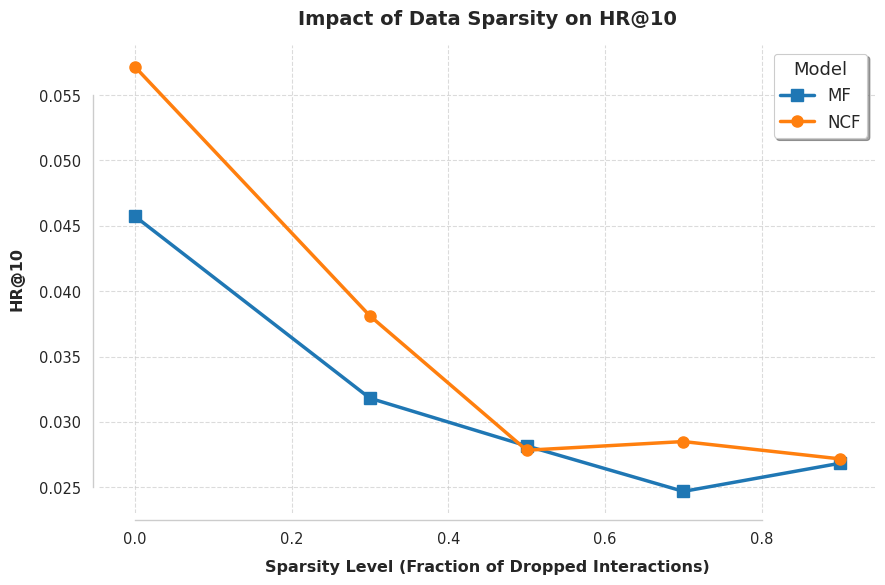

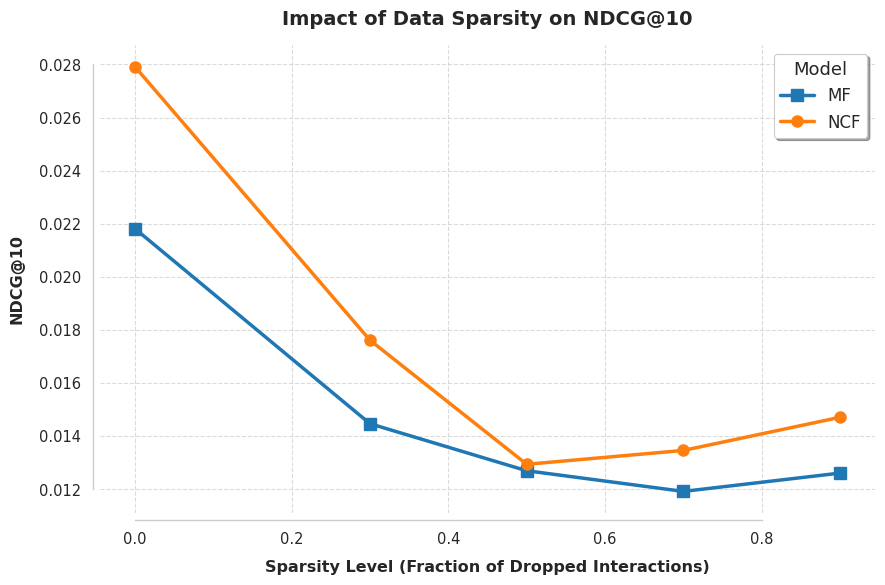

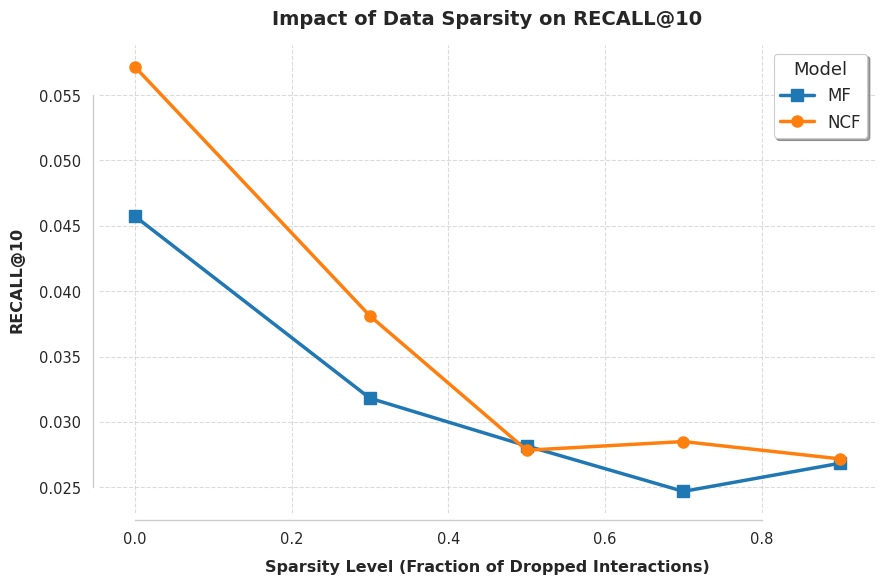

In [ ]:
# This cell creates line charts for the main ranking metrics.
# The graphs show how MF and NCF perform as sparsity increases.
# These figures can be used directly in the Results chapter of the dissertation.

import seaborn as sns

# Set a professional theme for the plots
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

figures_dir = out_dir / "figures"
figures_dir.mkdir(exist_ok=True)


def plot_metric_vs_sparsity(results_df, metric, output_path):
    plt.figure(figsize=(9, 6))

    # Use distinct colors and markers for the models
    colors = {"MF": "#1f77b4", "NCF": "#ff7f0e"}
    markers = {"MF": "s", "NCF": "o"}

    for model_name, group in results_df.groupby("model"):
        group = group.sort_values("sparsity_level")
        plt.plot(
            group["sparsity_level"],
            group[metric],
            marker=markers.get(model_name, "o"),
            markersize=8,
            linewidth=2.5,
            color=colors.get(model_name, "black"),
            label=model_name
        )

    plt.xlabel("Sparsity Level (Fraction of Dropped Interactions)", fontweight='bold', labelpad=10)
    plt.ylabel(f"{metric.upper()}@{CFG.top_k}", fontweight='bold', labelpad=10)
    plt.title(f"Impact of Data Sparsity on {metric.upper()}@{CFG.top_k}", fontsize=14, fontweight='bold', pad=15)

    plt.legend(title="Model", title_fontsize='13', fontsize='12', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Remove top and right borders for a cleaner look
    sns.despine(trim=True, offset=5)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


plot_metric_vs_sparsity(
    comparison_results_df,
    "hr",
    figures_dir / "hr_at_10_vs_sparsity.png"
)

plot_metric_vs_sparsity(
    comparison_results_df,
    "ndcg",
    figures_dir / "ndcg_at_10_vs_sparsity.png"
)

plot_metric_vs_sparsity(
    comparison_results_df,
    "recall",
    figures_dir / "recall_at_10_vs_sparsity.png"
)


### Additional Visualizations for Project Demonstration
Here we plot additional charts to compare the models holistically: overall performance at full data, computational efficiency (training time), and training loss convergence.

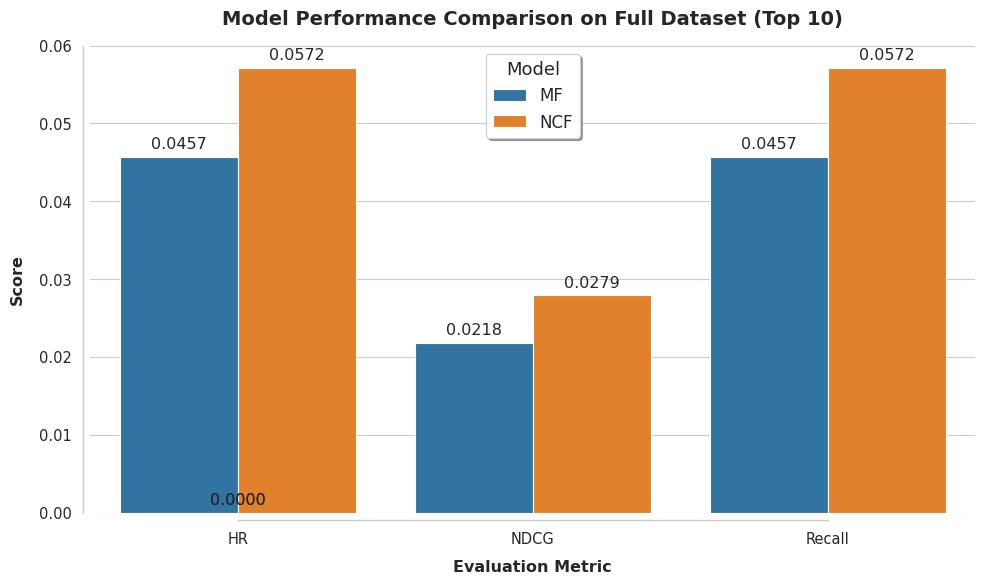

In [ ]:
# Visualization 1: Overall Performance Comparison at Full Data (keep_rate = 1.0)
full_data_results = comparison_results_df[comparison_results_df["keep_rate"] == 1.0].copy()

metrics_to_plot = ["hr", "ndcg", "recall"]
plot_data = full_data_results.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_data,
    x="metric",
    y="score",
    hue="model",
    palette={"MF": "#1f77b4", "NCF": "#ff7f0e"}
)

plt.title(f"Model Performance Comparison on Full Dataset (Top {CFG.top_k})", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Evaluation Metric", fontweight='bold', labelpad=10)
plt.ylabel("Score", fontweight='bold', labelpad=10)
plt.xticks(ticks=[0, 1, 2], labels=["HR", "NDCG", "Recall"])
plt.legend(title="Model", title_fontsize='13', fontsize='12', frameon=True, shadow=True)

# Annotate the bars with their values
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

sns.despine(trim=True, offset=5)
plt.tight_layout()
plt.savefig(figures_dir / "full_data_comparison_bar.png", dpi=300, bbox_inches='tight')
plt.show()

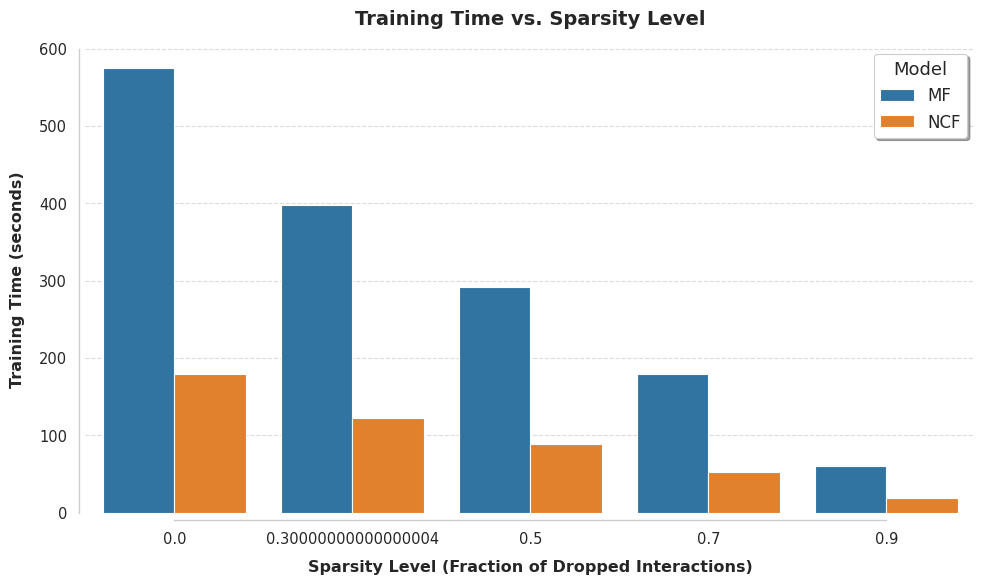

In [ ]:
# Visualization 2: Training Time Comparison across Sparsity Levels
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_results_df,
    x="sparsity_level",
    y="training_time_seconds",
    hue="model",
    palette={"MF": "#1f77b4", "NCF": "#ff7f0e"}
)

plt.title("Training Time vs. Sparsity Level", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sparsity Level (Fraction of Dropped Interactions)", fontweight='bold', labelpad=10)
plt.ylabel("Training Time (seconds)", fontweight='bold', labelpad=10)
plt.legend(title="Model", title_fontsize='13', fontsize='12', frameon=True, shadow=True)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
sns.despine(trim=True, offset=5)
plt.tight_layout()
plt.savefig(figures_dir / "training_time_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

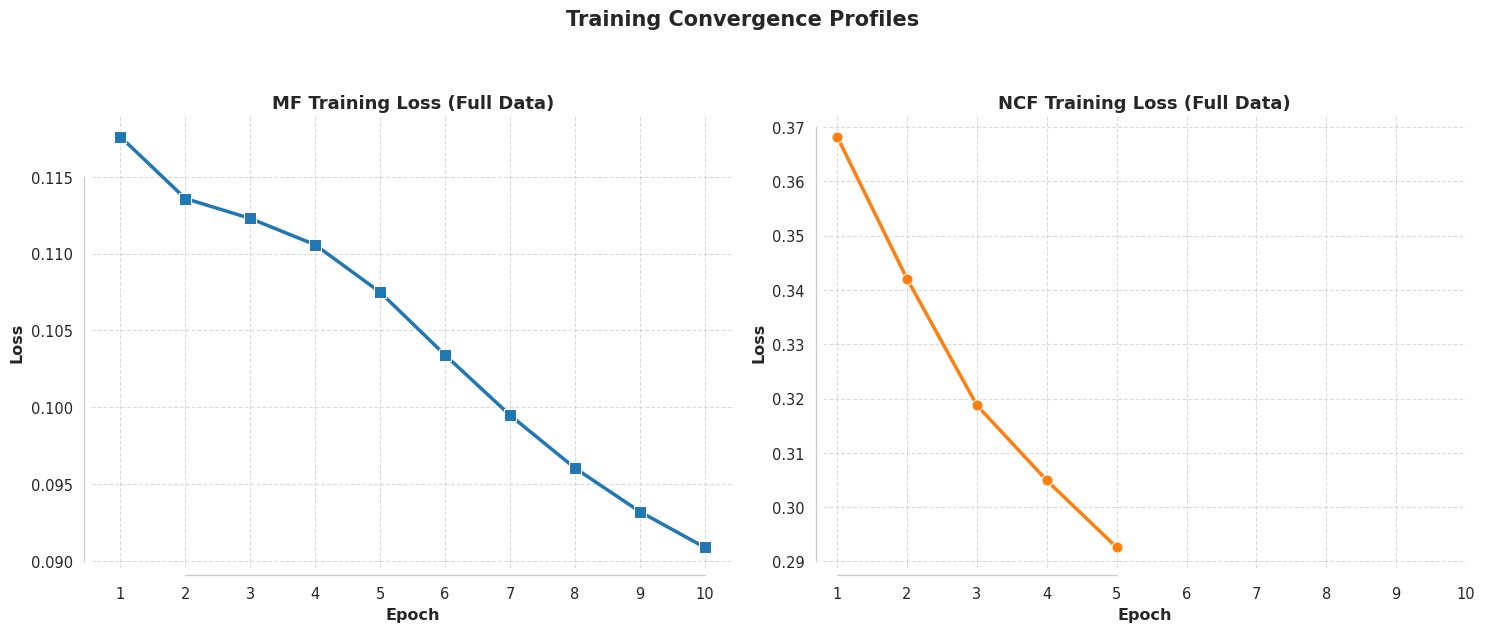

In [ ]:
# Visualization 3: Training Loss Convergence (Full Data)
# We use two subplots since MF and NCF might have different loss scales and epoch counts.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
full_loss_df = training_loss_df[training_loss_df["keep_rate"] == 1.0]

mf_loss = full_loss_df[full_loss_df["model"] == "MF"]
ncf_loss = full_loss_df[full_loss_df["model"] == "NCF"]

# MF Plot
sns.lineplot(ax=axes[0], data=mf_loss, x="epoch", y="loss", marker="s", color="#1f77b4", linewidth=2.5, markersize=8)
axes[0].set_title("MF Training Loss (Full Data)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch", fontweight='bold')
axes[0].set_ylabel("Loss", fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.7)

# NCF Plot
sns.lineplot(ax=axes[1], data=ncf_loss, x="epoch", y="loss", marker="o", color="#ff7f0e", linewidth=2.5, markersize=8)
axes[1].set_title("NCF Training Loss (Full Data)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch", fontweight='bold')
axes[1].set_ylabel("Loss", fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.7)

for ax in axes:
    sns.despine(ax=ax, trim=True, offset=5)
    ax.set_xticks(range(1, max(full_loss_df['epoch']) + 1))

plt.suptitle("Training Convergence Profiles", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(figures_dir / "training_loss_convergence.png", dpi=300, bbox_inches='tight')
plt.show()

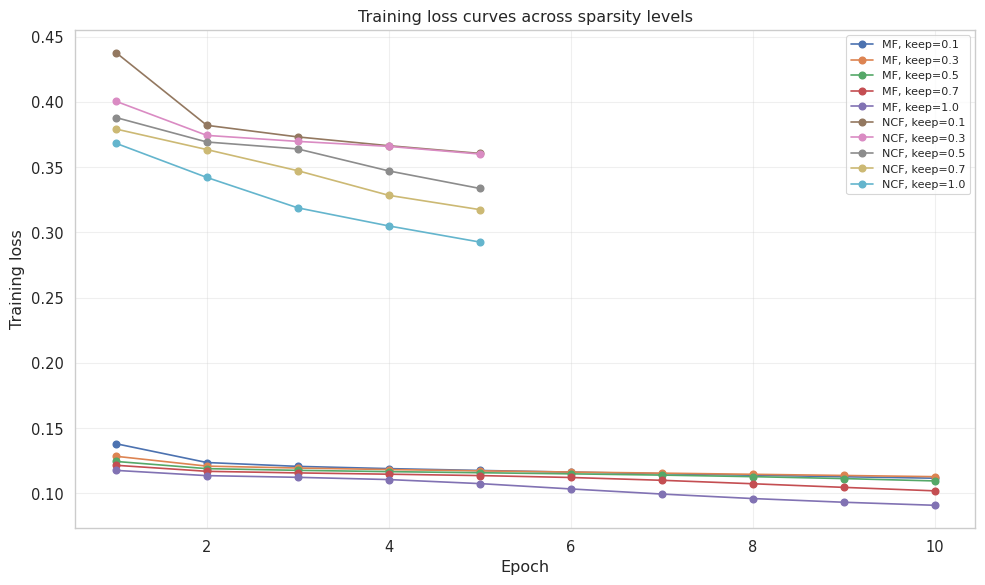

In [ ]:
# This cell plots training loss curves for MF and NCF.
# The graph helps compare convergence behaviour across models and sparsity levels.
# It can be used to discuss model stability and training efficiency.

plt.figure(figsize=(10, 6))

for (model_name, keep_rate), group in training_loss_df.groupby(["model", "keep_rate"]):
    group = group.sort_values("epoch")
    label = f"{model_name}, keep={keep_rate:.1f}"

    plt.plot(
        group["epoch"],
        group["loss"],
        marker="o",
        label=label
    )

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss curves across sparsity levels")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "training_losses_by_model_and_sparsity.png", dpi=300)
plt.show()

In [ ]:
# This cell displays the final comparison table.
# It allows direct inspection of MF and NCF performance at each sparsity level.

comparison_results_df.sort_values(
    ["keep_rate", "model"],
    ascending=[False, True]
)

,model,keep_rate,sparsity_level,k,hr,ndcg,recall,evaluated_users,train_interactions,train_density,training_time_seconds
0,MF,1.0,0.0,10,0.045741,0.021815,0.045741,6034,562308,0.029821,575.500384
1,NCF,1.0,0.0,10,0.057176,0.027919,0.057176,6034,562308,0.029821,179.165781
2,MF,0.7,0.3,10,0.031820,0.014464,0.031820,6034,396290,0.021016,397.332693
3,NCF,0.7,0.3,10,0.038117,0.017611,0.038117,6034,396290,0.021016,122.981029
4,MF,0.5,0.5,10,0.028174,0.012691,0.028174,6034,282674,0.015020,291.738901
5,NCF,0.5,0.5,10,0.027842,0.012935,0.027842,6034,282674,0.015020,88.412569
6,MF,0.3,0.7,10,0.024693,0.011913,0.024693,6034,171440,0.009189,179.863916
7,NCF,0.3,0.7,10,0.028505,0.013458,0.028505,6034,171440,0.009189,53.066469
8,MF,0.1,0.9,10,0.026848,0.012604,0.026848,6034,58922,0.003457,60.292444
9,NCF,0.1,0.9,10,0.027179,0.014707,0.027179,6034,58922,0.003457,18.423622


In [ ]:
# This cell downloads the output files from Google Colab.
# Download these CSV files so they can be used in the dissertation.

from google.colab import files

files.download("outputs/model_comparison_sparsity_results.csv")
files.download("outputs/model_comparison_training_losses.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Separate Amazon Digital Music Dataset Process

The following cells repeat the same MF vs NCF controlled sparsity experiment on the Amazon Digital Music 5-core dataset.  
This section is intended as the generalisation check for the dissertation, while keeping the original MovieLens workflow unchanged.

In [ ]:
# Download and load the Amazon Digital Music 5-core dataset for the generalisation check.

import urllib.request
import gzip
import shutil

AMAZON_DIGITAL_MUSIC_URL = (
    "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/"
    "categoryFilesSmall/Digital_Music_5.json.gz"
)

AMAZON_DIGITAL_MUSIC_PATH = "Digital_Music_5.json.gz"


def download_file_with_user_agent(url: str, output_path: str, timeout: int = 60) -> None:
    request = urllib.request.Request(
        url,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    with urllib.request.urlopen(request, timeout=timeout) as response:
        content = response.read()

    with open(output_path, "wb") as file:
        file.write(content)

    print(f"Downloaded: {output_path}")
    print(f"File size: {Path(output_path).stat().st_size} bytes")


def download_amazon_digital_music() -> None:
    amazon_file = Path(AMAZON_DIGITAL_MUSIC_PATH)

    if amazon_file.exists():
        try:
            with gzip.open(amazon_file, "rb") as file:
                file.read(1)
            print("Amazon Digital Music dataset already exists.")
            return
        except Exception:
            print("Removing corrupted Amazon Digital Music file.")
            amazon_file.unlink()

    print("Downloading Amazon Digital Music 5-core dataset...")
    download_file_with_user_agent(
        AMAZON_DIGITAL_MUSIC_URL,
        AMAZON_DIGITAL_MUSIC_PATH
    )

    try:
        with gzip.open(amazon_file, "rb") as file:
            file.read(1)
    except Exception as error:
        raise RuntimeError(
            "Amazon Digital Music download failed because the file is not a valid gzip file."
        ) from error

    print("Amazon Digital Music download complete.")


def load_amazon_digital_music(path: str) -> pd.DataFrame:
    amazon_df = pd.read_json(
        path,
        lines=True,
        compression="gzip"
    )

    amazon_df = amazon_df.rename(
        columns={
            "reviewerID": "user_id",
            "asin": "item_id",
            "overall": "rating",
            "unixReviewTime": "timestamp"
        }
    )

    required_columns = ["user_id", "item_id", "rating", "timestamp"]
    amazon_df = amazon_df[required_columns].dropna()

    return amazon_df


download_amazon_digital_music()
amazon_ratings = load_amazon_digital_music(AMAZON_DIGITAL_MUSIC_PATH)

print("Amazon Digital Music raw ratings:", len(amazon_ratings))
amazon_ratings.head()

Downloaded: Digital_Music_5.json.gz
File size: 19457656 bytes
Amazon Digital Music download complete.
Amazon Digital Music raw ratings: 169781


,user_id,item_id,rating,timestamp
0,A2TYZ821XXK2YZ,3426958910,5,1370217600
1,A3OFSREZADFUDY,3426958910,5,1412985600
2,A2VAMODP8M77NG,3426958910,5,1392076800
3,AAKSLZ9IDTEH0,3426958910,4,1386374400
4,A3OH43OZJLKI09,5557706259,5,1465689600


In [ ]:
# Prepare Amazon Digital Music using the same preprocessing logic as MovieLens.

amazon_interactions = preprocess_interactions(
    amazon_ratings,
    CFG.implicit_threshold
)

amazon_interactions = filter_min_interactions(
    amazon_interactions,
    CFG.min_user_interactions,
    CFG.min_item_interactions
)

amazon_interactions, amazon_user_map, amazon_item_map = encode_ids(amazon_interactions)

amazon_n_users = amazon_interactions["user_idx"].nunique()
amazon_n_items = amazon_interactions["item_idx"].nunique()

amazon_train_df, amazon_val_df, amazon_test_df = userwise_leave_one_out_split(
    amazon_interactions
)

amazon_stats_df = pd.DataFrame([
    dataset_stats(amazon_train_df, "amazon_train"),
    dataset_stats(amazon_val_df, "amazon_validation"),
    dataset_stats(amazon_test_df, "amazon_test")
])

amazon_out_dir = Path("outputs") / "amazon_digital_music"
amazon_out_dir.mkdir(parents=True, exist_ok=True)

amazon_stats_df.to_csv(
    amazon_out_dir / "amazon_dataset_statistics.csv",
    index=False
)

print("Amazon positive implicit interactions:", len(amazon_interactions))
print("Amazon users:", amazon_n_users)
print("Amazon items:", amazon_n_items)
print("Amazon train interactions:", len(amazon_train_df))
print("Amazon validation interactions:", len(amazon_val_df))
print("Amazon test interactions:", len(amazon_test_df))

amazon_stats_df

Amazon positive implicit interactions: 145523
Amazon users: 14354
Amazon items: 10027
Amazon train interactions: 116815
Amazon validation interactions: 14354
Amazon test interactions: 14354


,label,users,items,interactions,density,sparsity
0,amazon_train,14354,10010,116815,0.000813,0.999187
1,amazon_validation,14354,6677,14354,0.000150,0.999850
2,amazon_test,14354,6667,14354,0.000150,0.999850


In [ ]:
# Train and evaluate MF and NCF separately on Amazon Digital Music across controlled sparsity levels.

amazon_comparison_results = []
amazon_training_loss_rows = []

amazon_start_time = time.time()

for keep_rate in CFG.sparsity_keep_rates:
    print("\n" + "=" * 70)
    print(f"Amazon Digital Music | Sparsity experiment | keep_rate = {keep_rate}")
    print("=" * 70)

    amazon_sparse_train = apply_controlled_sparsity(
        amazon_train_df,
        keep_rate,
        seed=CFG.seed
    )

    amazon_train_density = dataset_stats(
        amazon_sparse_train,
        "amazon_sparse_train"
    )["density"]

    amazon_train_binary = generate_binary_training_data(
        train_df=amazon_sparse_train,
        n_items=amazon_n_items,
        negative_ratio=CFG.negative_ratio,
        seed=CFG.seed
    )

    print("Amazon sparse train interactions:", len(amazon_sparse_train))
    print("Amazon binary training rows:", len(amazon_train_binary))
    print("Amazon training density:", amazon_train_density)

    # Train and evaluate Matrix Factorization on Amazon Digital Music.
    print("\nTraining Matrix Factorization on Amazon Digital Music...")

    amazon_mf = MatrixFactorization(
        n_users=amazon_n_users,
        n_items=amazon_n_items,
        n_factors=CFG.mf_factors,
        learning_rate=CFG.mf_learning_rate,
        reg=CFG.mf_reg,
        n_epochs=CFG.mf_epochs,
        seed=CFG.seed
    )

    amazon_mf_start = time.time()
    amazon_mf_losses = amazon_mf.fit(amazon_train_binary)
    amazon_mf_training_time = time.time() - amazon_mf_start

    for epoch, loss in enumerate(amazon_mf_losses, start=1):
        amazon_training_loss_rows.append({
            "dataset": "Amazon Digital Music",
            "model": "MF",
            "keep_rate": keep_rate,
            "sparsity_level": 1.0 - keep_rate,
            "epoch": epoch,
            "loss": loss
        })

    amazon_mf_metrics = evaluate_model_ranking(
        model=amazon_mf,
        train_df=amazon_sparse_train,
        test_df=amazon_test_df,
        k=CFG.top_k
    )

    amazon_comparison_results.append({
        "dataset": "Amazon Digital Music",
        "model": "MF",
        "keep_rate": keep_rate,
        "sparsity_level": 1.0 - keep_rate,
        "k": CFG.top_k,
        "hr": amazon_mf_metrics["HR@K"],
        "ndcg": amazon_mf_metrics["NDCG@K"],
        "recall": amazon_mf_metrics["Recall@K"],
        "evaluated_users": amazon_mf_metrics["evaluated_users"],
        "train_interactions": len(amazon_sparse_train),
        "train_density": amazon_train_density,
        "training_time_seconds": amazon_mf_training_time
    })

    print(f"Amazon MF HR@{CFG.top_k}: {amazon_mf_metrics['HR@K']:.4f}")
    print(f"Amazon MF NDCG@{CFG.top_k}: {amazon_mf_metrics['NDCG@K']:.4f}")
    print(f"Amazon MF Recall@{CFG.top_k}: {amazon_mf_metrics['Recall@K']:.4f}")
    print(f"Amazon MF training time: {amazon_mf_training_time:.2f} seconds")

    # Train and evaluate Neural Collaborative Filtering on Amazon Digital Music.
    print("\nTraining Neural Collaborative Filtering on Amazon Digital Music...")

    amazon_ncf = NCFRecommender(
        n_users=amazon_n_users,
        n_items=amazon_n_items,
        embedding_dim=CFG.ncf_embedding_dim,
        hidden_layers=CFG.ncf_hidden_layers,
        dropout=CFG.ncf_dropout,
        learning_rate=CFG.ncf_learning_rate,
        batch_size=CFG.ncf_batch_size,
        n_epochs=CFG.ncf_epochs,
        seed=CFG.seed,
        device=device
    )

    amazon_ncf_start = time.time()
    amazon_ncf_losses = amazon_ncf.fit(amazon_train_binary)
    amazon_ncf_training_time = time.time() - amazon_ncf_start

    for epoch, loss in enumerate(amazon_ncf_losses, start=1):
        amazon_training_loss_rows.append({
            "dataset": "Amazon Digital Music",
            "model": "NCF",
            "keep_rate": keep_rate,
            "sparsity_level": 1.0 - keep_rate,
            "epoch": epoch,
            "loss": loss
        })

    amazon_ncf_metrics = evaluate_model_ranking(
        model=amazon_ncf,
        train_df=amazon_sparse_train,
        test_df=amazon_test_df,
        k=CFG.top_k
    )

    amazon_comparison_results.append({
        "dataset": "Amazon Digital Music",
        "model": "NCF",
        "keep_rate": keep_rate,
        "sparsity_level": 1.0 - keep_rate,
        "k": CFG.top_k,
        "hr": amazon_ncf_metrics["HR@K"],
        "ndcg": amazon_ncf_metrics["NDCG@K"],
        "recall": amazon_ncf_metrics["Recall@K"],
        "evaluated_users": amazon_ncf_metrics["evaluated_users"],
        "train_interactions": len(amazon_sparse_train),
        "train_density": amazon_train_density,
        "training_time_seconds": amazon_ncf_training_time
    })

    print(f"Amazon NCF HR@{CFG.top_k}: {amazon_ncf_metrics['HR@K']:.4f}")
    print(f"Amazon NCF NDCG@{CFG.top_k}: {amazon_ncf_metrics['NDCG@K']:.4f}")
    print(f"Amazon NCF Recall@{CFG.top_k}: {amazon_ncf_metrics['Recall@K']:.4f}")
    print(f"Amazon NCF training time: {amazon_ncf_training_time:.2f} seconds")


amazon_total_time = time.time() - amazon_start_time
print("\nAmazon Digital Music experiment time:", round(amazon_total_time, 2), "seconds")


Amazon Digital Music | Sparsity experiment | keep_rate = 1.0
Amazon sparse train interactions: 116815
Amazon binary training rows: 584075
Amazon training density: 0.0008130019625073268

Training Matrix Factorization on Amazon Digital Music...
MF Epoch 1/10 - loss: 0.152278
MF Epoch 2/10 - loss: 0.141071
MF Epoch 3/10 - loss: 0.137167
MF Epoch 4/10 - loss: 0.134720
MF Epoch 5/10 - loss: 0.132716
MF Epoch 6/10 - loss: 0.130900
MF Epoch 7/10 - loss: 0.129169
MF Epoch 8/10 - loss: 0.127498
MF Epoch 9/10 - loss: 0.125832
MF Epoch 10/10 - loss: 0.124178
Amazon MF HR@10: 0.0103
Amazon MF NDCG@10: 0.0064
Amazon MF Recall@10: 0.0103
Amazon MF training time: 126.20 seconds

Training Neural Collaborative Filtering on Amazon Digital Music...
NCF Epoch 1/5 - loss: 0.472736
NCF Epoch 2/5 - loss: 0.438405
NCF Epoch 3/5 - loss: 0.420423
NCF Epoch 4/5 - loss: 0.395173
NCF Epoch 5/5 - loss: 0.361520
Amazon NCF HR@10: 0.0105
Amazon NCF NDCG@10: 0.0066
Amazon NCF Recall@10: 0.0105
Amazon NCF training tim

In [ ]:
# Save Amazon Digital Music results and training losses.

amazon_comparison_results_df = pd.DataFrame(amazon_comparison_results)
amazon_training_loss_df = pd.DataFrame(amazon_training_loss_rows)

amazon_comparison_results_df.to_csv(
    amazon_out_dir / "amazon_model_comparison_sparsity_results.csv",
    index=False
)

amazon_training_loss_df.to_csv(
    amazon_out_dir / "amazon_model_comparison_training_losses.csv",
    index=False
)

amazon_comparison_results_df.sort_values(
    ["keep_rate", "model"],
    ascending=[False, True]
)

,dataset,model,keep_rate,sparsity_level,k,hr,ndcg,recall,evaluated_users,train_interactions,train_density,training_time_seconds
0,Amazon Digital Music,MF,1.0,0.0,10,0.010311,0.006385,0.010311,14354,116815,0.000813,126.202539
1,Amazon Digital Music,NCF,1.0,0.0,10,0.010520,0.006606,0.010520,14354,116815,0.000813,40.982841
2,Amazon Digital Music,MF,0.7,0.3,10,0.011983,0.006838,0.011983,14354,89535,0.000627,98.522989
3,Amazon Digital Music,NCF,0.7,0.3,10,0.011774,0.007101,0.011774,14354,89535,0.000627,31.870176
4,Amazon Digital Music,MF,0.5,0.5,10,0.011356,0.006633,0.011356,14354,62641,0.000450,67.838233
5,Amazon Digital Music,NCF,0.5,0.5,10,0.010729,0.006760,0.010729,14354,62641,0.000450,21.980498
6,Amazon Digital Music,MF,0.3,0.7,10,0.012122,0.006998,0.012122,14354,41069,0.000316,44.798874
7,Amazon Digital Music,NCF,0.3,0.7,10,0.013376,0.007977,0.013376,14354,41069,0.000316,13.751083
8,Amazon Digital Music,MF,0.1,0.9,10,0.011356,0.006446,0.011356,14354,19149,0.000189,19.411532
9,Amazon Digital Music,NCF,0.1,0.9,10,0.012470,0.007029,0.012470,14354,19149,0.000189,6.399850


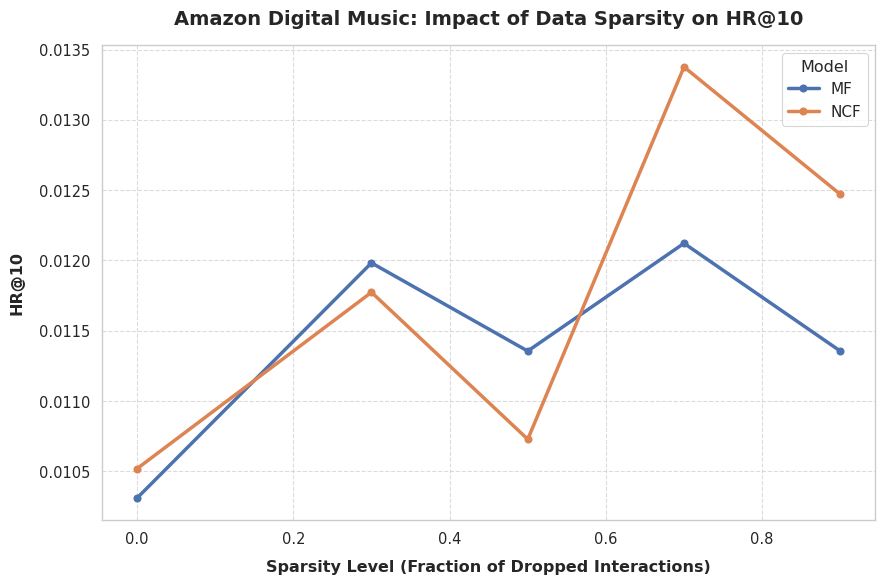

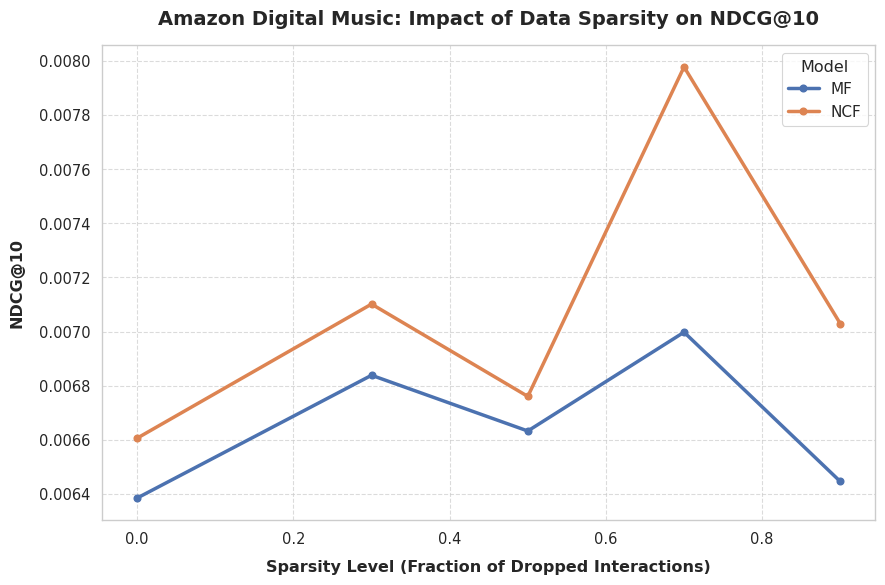

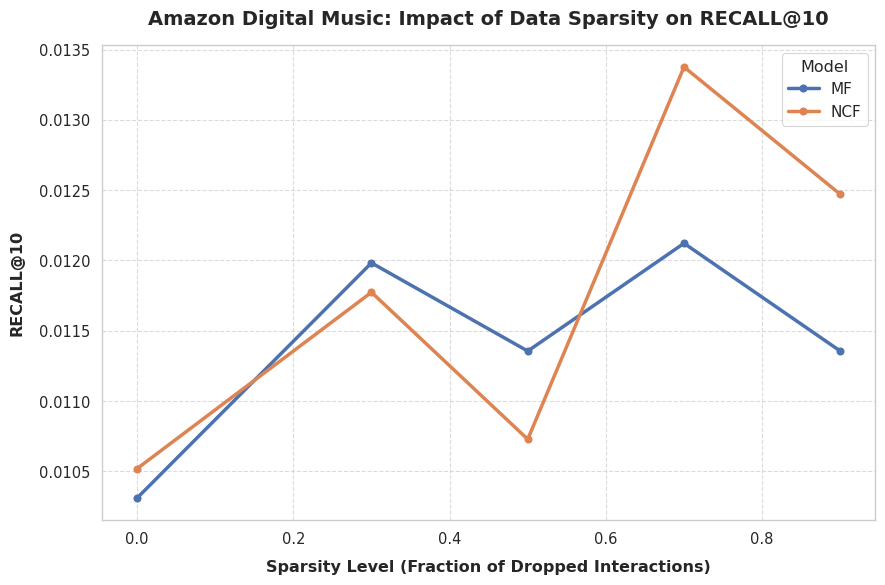

In [ ]:
# Plot Amazon Digital Music ranking metrics across controlled sparsity levels.

amazon_figures_dir = amazon_out_dir / "figures"
amazon_figures_dir.mkdir(exist_ok=True)


def plot_amazon_metric_vs_sparsity(results_df, metric, output_path):
    plt.figure(figsize=(9, 6))

    for model_name, group in results_df.groupby("model"):
        group = group.sort_values("sparsity_level")
        plt.plot(
            group["sparsity_level"],
            group[metric],
            marker="o",
            linewidth=2.5,
            label=model_name
        )

    plt.xlabel("Sparsity Level (Fraction of Dropped Interactions)", fontweight="bold", labelpad=10)
    plt.ylabel(f"{metric.upper()}@{CFG.top_k}", fontweight="bold", labelpad=10)
    plt.title(
        f"Amazon Digital Music: Impact of Data Sparsity on {metric.upper()}@{CFG.top_k}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    plt.legend(title="Model", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_amazon_metric_vs_sparsity(
    amazon_comparison_results_df,
    "hr",
    amazon_figures_dir / "amazon_hr_at_10_vs_sparsity.png"
)

plot_amazon_metric_vs_sparsity(
    amazon_comparison_results_df,
    "ndcg",
    amazon_figures_dir / "amazon_ndcg_at_10_vs_sparsity.png"
)

plot_amazon_metric_vs_sparsity(
    amazon_comparison_results_df,
    "recall",
    amazon_figures_dir / "amazon_recall_at_10_vs_sparsity.png"
)

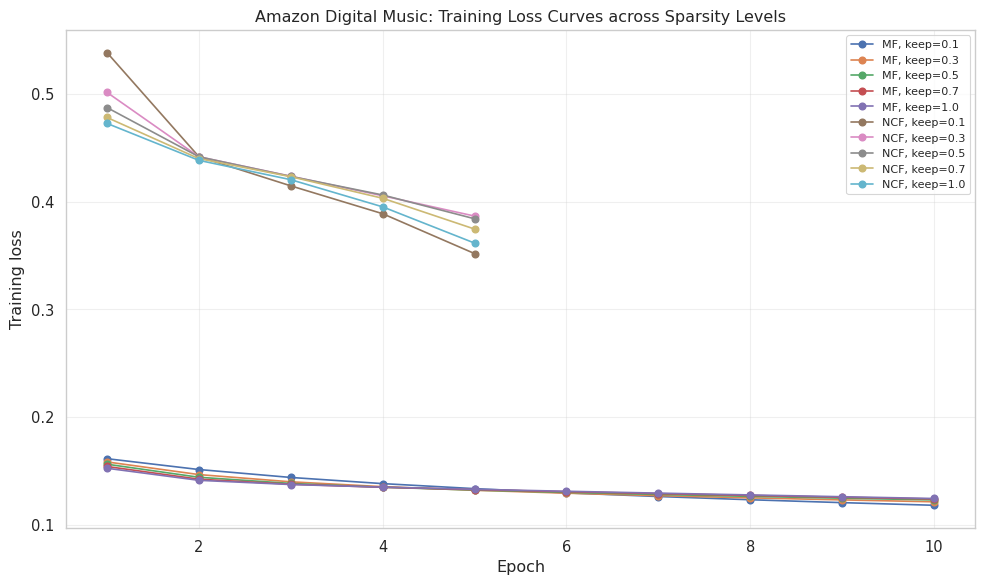

In [ ]:
# Plot Amazon Digital Music training loss curves.

plt.figure(figsize=(10, 6))

for (model_name, keep_rate), group in amazon_training_loss_df.groupby(["model", "keep_rate"]):
    group = group.sort_values("epoch")
    label = f"{model_name}, keep={keep_rate:.1f}"

    plt.plot(
        group["epoch"],
        group["loss"],
        marker="o",
        label=label
    )

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Amazon Digital Music: Training Loss Curves across Sparsity Levels")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    amazon_figures_dir / "amazon_training_losses_by_model_and_sparsity.png",
    dpi=300
)
plt.show()

In [ ]:
# Combine MovieLens and Amazon results when MovieLens results are already available.

if "comparison_results_df" in globals():
    combined_comparison_results_df = pd.concat(
        [
            comparison_results_df.assign(dataset="MovieLens 1M"),
            amazon_comparison_results_df
        ],
        ignore_index=True
    )

    combined_comparison_results_df.to_csv(
        Path("outputs") / "combined_movielens_amazon_comparison_results.csv",
        index=False
    )

    display(
        combined_comparison_results_df.sort_values(
            ["dataset", "keep_rate", "model"],
            ascending=[True, False, True]
        )
    )
else:
    print("MovieLens comparison_results_df not found. Run the MovieLens experiment first if you want a combined table.")

,model,keep_rate,sparsity_level,k,hr,ndcg,recall,evaluated_users,train_interactions,train_density,training_time_seconds,dataset
10,MF,1.0,0.0,10,0.010311,0.006385,0.010311,14354,116815,0.000813,126.202539,Amazon Digital Music
11,NCF,1.0,0.0,10,0.010520,0.006606,0.010520,14354,116815,0.000813,40.982841,Amazon Digital Music
12,MF,0.7,0.3,10,0.011983,0.006838,0.011983,14354,89535,0.000627,98.522989,Amazon Digital Music
13,NCF,0.7,0.3,10,0.011774,0.007101,0.011774,14354,89535,0.000627,31.870176,Amazon Digital Music
14,MF,0.5,0.5,10,0.011356,0.006633,0.011356,14354,62641,0.000450,67.838233,Amazon Digital Music
15,NCF,0.5,0.5,10,0.010729,0.006760,0.010729,14354,62641,0.000450,21.980498,Amazon Digital Music
16,MF,0.3,0.7,10,0.012122,0.006998,0.012122,14354,41069,0.000316,44.798874,Amazon Digital Music
17,NCF,0.3,0.7,10,0.013376,0.007977,0.013376,14354,41069,0.000316,13.751083,Amazon Digital Music
18,MF,0.1,0.9,10,0.011356,0.006446,0.011356,14354,19149,0.000189,19.411532,Amazon Digital Music
19,NCF,0.1,0.9,10,0.012470,0.007029,0.012470,14354,19149,0.000189,6.399850,Amazon Digital Music


In [ ]:
# Download Amazon Digital Music output files from Google Colab.

from google.colab import files

files.download(str(amazon_out_dir / "amazon_model_comparison_sparsity_results.csv"))
files.download(str(amazon_out_dir / "amazon_model_comparison_training_losses.csv"))

files.download(str(amazon_figures_dir / "amazon_hr_at_10_vs_sparsity.png"))
files.download(str(amazon_figures_dir / "amazon_ndcg_at_10_vs_sparsity.png"))
files.download(str(amazon_figures_dir / "amazon_recall_at_10_vs_sparsity.png"))
files.download(str(amazon_figures_dir / "amazon_training_losses_by_model_and_sparsity.png"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>